# Normative modelling tutorial

Welcome to this tutorial notebook that will go through the fitting, evaluation, transfering, and extending of Normative models. 

Let's jump right in.

### Imports

In [1]:
import warnings
import logging


import pandas as pd
import matplotlib.pyplot as plt
from pcntoolkit import (
    BLR,
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    SHASHbLikelihood,
    NormalLikelihood,
    make_prior,
    plot_centiles,
    plot_qq,
    plot_ridge,
)

import numpy as np
import pcntoolkit.util.output
import seaborn as sns
import os

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(False)

# Load data

First we download a small example dataset from github.

In [2]:
# Download the dataset
norm_data: NormData = load_fcon1000()
features_to_model = [
    "WM-hypointensities",
    # "Right-Lateral-Ventricle",
    # "Right-Amygdala",
    # "CortexVol",
]
# Select only a few features
norm_data = norm_data.sel({"response_vars": features_to_model})
# Leave two sites out for doing transfer and extend later
transfer_sites = ["Milwaukee_b", "Oulu"]
transfer_data, fit_data = norm_data.batch_effects_split({"site": transfer_sites}, names=("transfer", "fit"))

# Split into train and test sets
train, test = fit_data.train_test_split()
transfer_train, transfer_test = transfer_data.train_test_split()


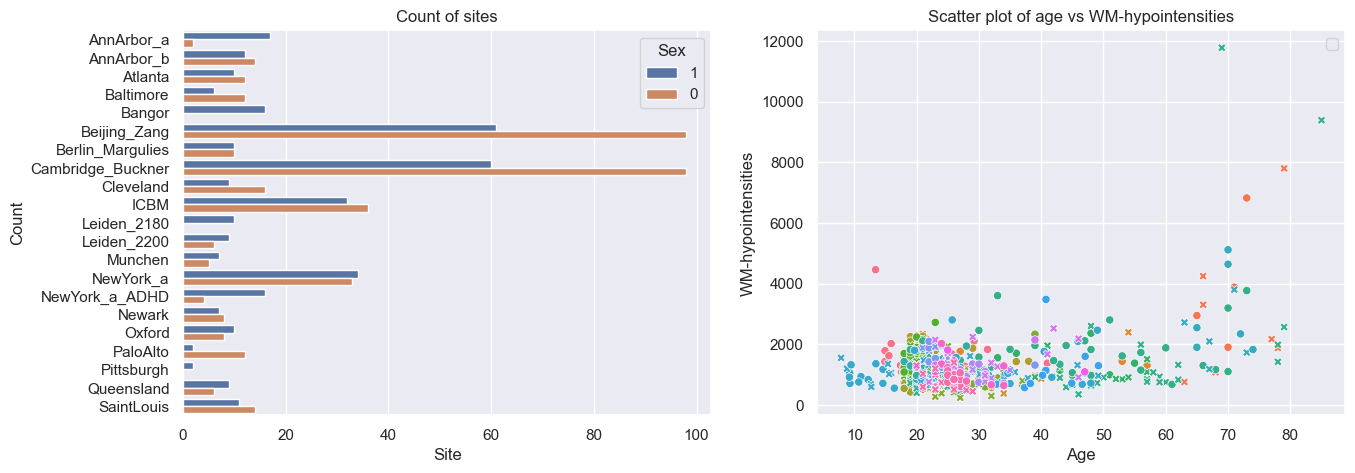

In [3]:
# Inspect the data
feature_to_plot = features_to_model[0]
df = train.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, y=("batch_effects", "site"), hue=("batch_effects", "sex"), ax=ax[0], orient="h")
ax[0].legend(title="Sex")
ax[0].set_title("Count of sites")
ax[0].set_xlabel("Site")
ax[0].set_ylabel("Count")


sns.scatterplot(
    data=df,
    x=("X", "age"),
    y=("Y", feature_to_plot),
    hue=("batch_effects", "site"),
    style=("batch_effects", "sex"),
    ax=ax[1],
)
ax[1].legend([], [])
ax[1].set_title(f"Scatter plot of age vs {feature_to_plot}")
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)

plt.show()

# Creating a Normative model

A normative model has a regression model for each response variable. We provide a template regression model which is copied for each response variable. 

A template regression model can be anything that implements the `RegressionModel` interface. We provide a number of built-in regression models, but you can also create your own. 

Here we use the `HBR` class, which implements a Hierarchical Bayesian Regression model. 

The `HBR` class needs to know which likelihood function to use. We can either use a Normal, SHASHo, SHASHb, or Beta likelihood. Each of these likelihood functions has a number of parameters that need to be specified. 

Here we use the Normal likelihood. This takes a mu and a sigma parameter, which can be created using the `make_prior` function, or by providing the 'Prior' directly. 

Here we use the `make_prior` function to create the parameters. 

In [4]:
mu = make_prior(
    # Mu is linear because we want to allow the mean to vary as a function of the covariates.
    linear=True,
    # The slope coefficients are assumed to be normally distributed, with a mean of 0 and a standard deviation of 10.
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    # The intercept is random, because we expect the intercept to vary between sites and sexes.
    intercept=make_prior(
        random=True,
        # Mu is the mean of the intercept, which is normally distributed with a mean of 0 and a standard deviation of 1.
        mu=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        # Sigma is the scale at which the intercepts vary. It is a positive parameter, so we have to map it to the positive domain.
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
    # We use a B-spline basis function to allow for non-linearity in the mean.
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma = make_prior(
    # Sigma is also linear, because we want to allow the standard deviation to vary as a function of the covariates: heteroskedasticity.
    linear=True,
    # The slope coefficients are assumed to be normally distributed, with a mean of 0 and a standard deviation of 2.
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    # The intercept is random, because we expect the intercept to vary between sites and sexes.
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    # We use a B-spline basis function to allow for non-linearity in the standard deviation.
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    # We use a softplus mapping to ensure that sigma is strictly positive.
    mapping="softplus",
    # We scale the softplus mapping by a factor of 3, to avoid spikes in the resulting density.
    # The parameters (a, b, c) provided to a mapping f are used as: f_abc(x) = f((x - a) / b) * b + c
    # This basically provides an affine transformation of the softplus function.
    # a -> horizontal shift
    # b -> scaling
    # c -> vertical shift
    # You can leave c out, and it will default to 0.
    mapping_params=(0.0, 3.0),
)

template_hbr = HBR(
    name="template",
    # The number of cores to use for sampling.
    cores=16,
    # Whether to show a progress bar during the model fitting.
    progressbar=True,
    # The number of draws to sample from the posterior per chain.
    draws=1500,
    # The number of tuning steps to run.
    tune=500,
    # The number of MCMC chains to run.
    chains=4,
    # The sampler to use for the model.
    nuts_sampler="nutpie",
    # The likelihood function to use for the model.
    likelihood=NormalLikelihood(
        mu,
        sigma,
    ),
)

After specifying the regression model, we can configure a normative model. 

A normative model has a number of configuration options:
- `savemodel`: Whether to save the model after fitting.
- `evaluate_model`: Whether to evaluate the model after fitting.
- `saveresults`: Whether to save the results after evaluation.
- `saveplots`: Whether to save the plots after fitting.
- `save_dir`: The directory to save the model, results, and plots.
- `inscaler`: The scaler to use for the input data.
- `outscaler`: The scaler to use for the output data.




In [5]:
model = NormativeModel(
    # The regression model to use for the normative model.
    template_regression_model=template_hbr,
    # Whether to save the model after fitting.
    savemodel=True,
    # Whether to evaluate the model after fitting.
    evaluate_model=True,
    # Whether to save the results after evaluation.
    saveresults=True,
    # Whether to save the plots after fitting.
    saveplots=False,
    # The directory to save the model, results, and plots.
    save_dir="resources/hbr/save_dir",
    # The scaler to use for the input data. Can be either one of "standardize", "minmax", "robustminmax", "none"
    inscaler="standardize",
    # The scaler to use for the output data. Can be either one of "standardize", "minmax", "robustminmax", "none"
    outscaler="standardize",
)

# Fit the model


With all that configured, we can fit the model. 

The `fit_predict` function will fit the model, evaluate it, and save the results and plots (if so configured). 

After that, it will compute Z-scores and centiles for the test set. 

All results can be found in the save directory. 

In [6]:
test = model.fit_predict(train, test)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,12,0.13,127
,2000,85,0.12,31
,2000,5,0.11,127
,2000,18,0.11,95


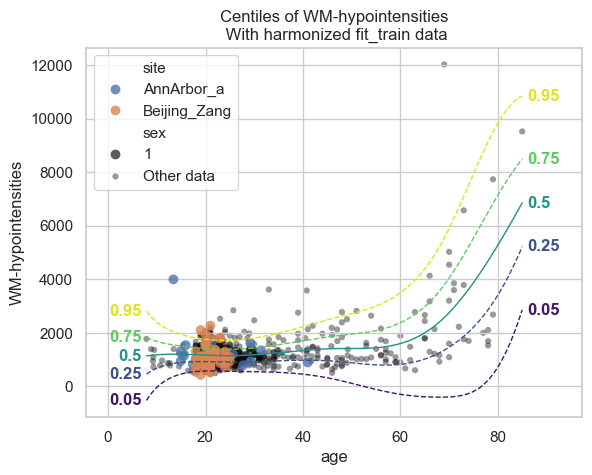

In [7]:
plot_centiles(
    model,
    scatter_data=train,  # Scatter this data along with the centiles
    batch_effects={"site": ["Beijing_Zang", "AnnArbor_a"], "sex": ["1"]},  # Highlight these groups
    show_other_data=True,  # scatter other data as smaller black circles
)

In [8]:
# If predictions are made on a dataset, the model evaluation statistics are stored in the dataset.
display(train.get_statistics_df())
display(test.get_statistics_df())

statistic,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
response_vars,,,,,,,,,,
WM-hypointensities,0.04,14.4,0.64,0.78,0.39,0.78,0.55,0.0,0.61,0.91


statistic,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
response_vars,,,,,,,,,,
WM-hypointensities,0.03,5.2,0.37,0.86,0.42,0.63,0.57,0.0,0.58,0.94


# Now what?

Now we have a normative model, we can use it to:
- Harmonize data
- Synthesize data
- Map data to Z-scores
- Plot centiles
- Plot QQ-plots
- Plot ridge plots
- Save the model
- Send it to a colleague
- Load it from file
- Transfer the model to another dataset
- Extend the model to another dataset

In [9]:
# turn this off because it costs time
model.savemodel = False
model.saveresults = False
model.saveplots = False
model.evaluate_model = False

### Harmonize

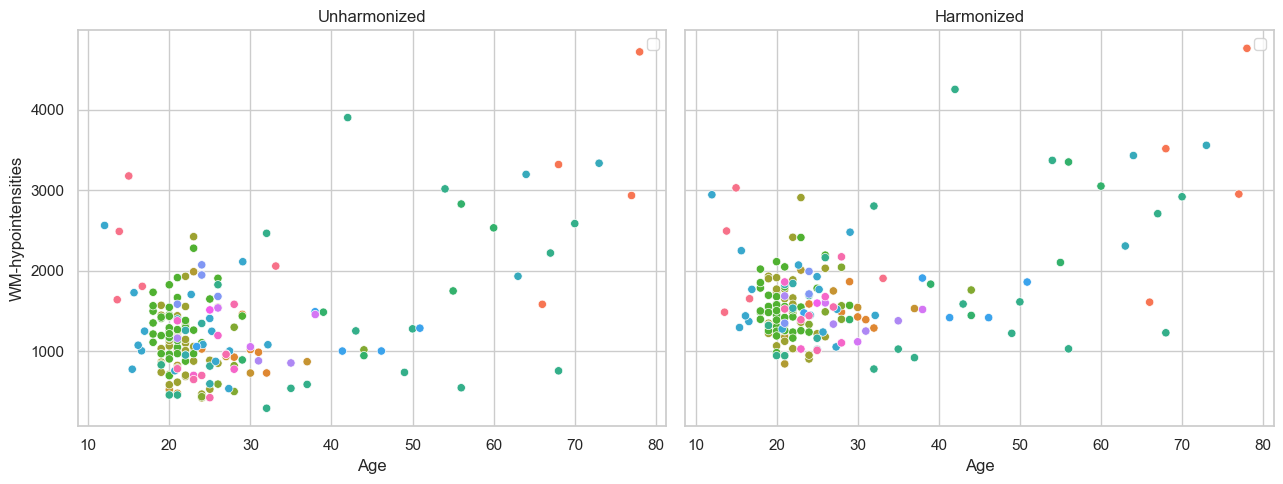

In [10]:
model.harmonize(test)  # <- easy

df = test.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
sns.scatterplot(data=df, x=("X", "age"), y=("Y", feature_to_plot), hue=("batch_effects", "site"), ax=ax[0])
sns.scatterplot(data=df, x=("X", "age"), y=("Y_harmonized", feature_to_plot), hue=("batch_effects", "site"), ax=ax[1])
ax[0].title.set_text("Unharmonized")
ax[1].title.set_text("Harmonized")
ax[0].legend([], [])
ax[1].legend([], [])
ax[0].set_xlabel("Age")
ax[0].set_ylabel(feature_to_plot)
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)
plt.tight_layout()
plt.show()

### Synthesize

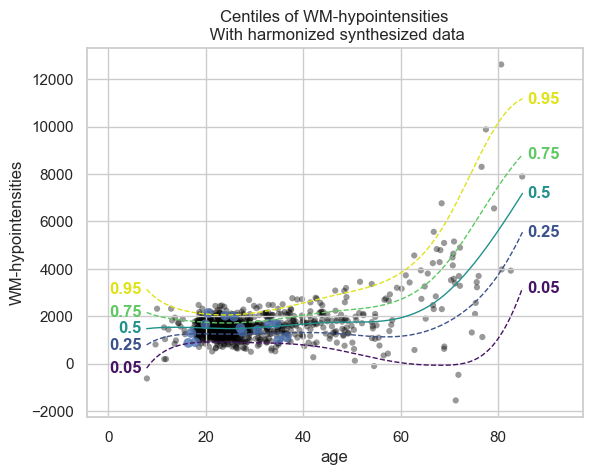

In [11]:
synthetic_data = model.synthesize(covariate_range_per_batch_effect=True)  # <- also easy
plot_centiles(
    model,
    covariate="age",  # Which covariate to plot on the x-axis
    scatter_data=synthetic_data,
    show_other_data=True,
    harmonize_data=True,
    show_legend=False,
)


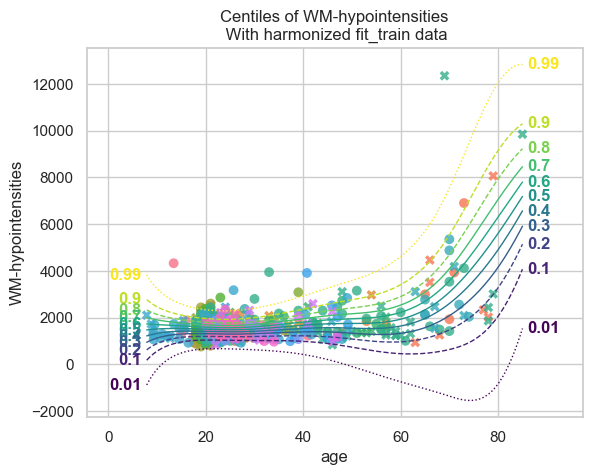

In [ ]:
# Synthesize new Y data for existing X data
new_test_data = test.copy()

if hasattr(new_test_data, "Y"):
    del new_test_data["Y"]

synthetic = model.synthesize(new_test_data)  # <- will fill in the missing Y data
plot_centiles(
    model,
    centiles=[0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99],  # Plot arbitrary centiles
    covariate="age",  # Which covariate to plot on the x-axis
    scatter_data=train,  # Scatter the train data points
    batch_effects="all",  # You can set this to "all" to show all batch effects
    show_other_data=True,  # Show data points that do not match any batch effects
    harmonize_data=True,  # Set this to False to see the difference
    show_legend=False,  # Don't show the legend because it crowds the plot
)

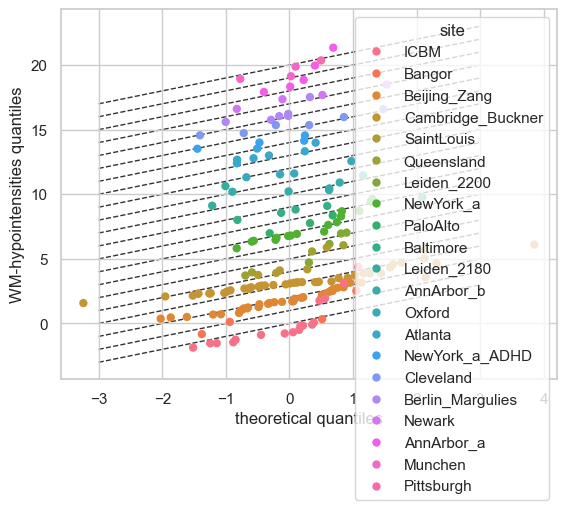

In [13]:
plot_qq(test, plot_id_line=True, hue_data="site", split_data="site")
sns.set_theme(style="darkgrid", rc={"axes.facecolor": (0, 0, 0, 0)})


/opt/anaconda3/envs/uv_refactor/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/uv_refactor/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)


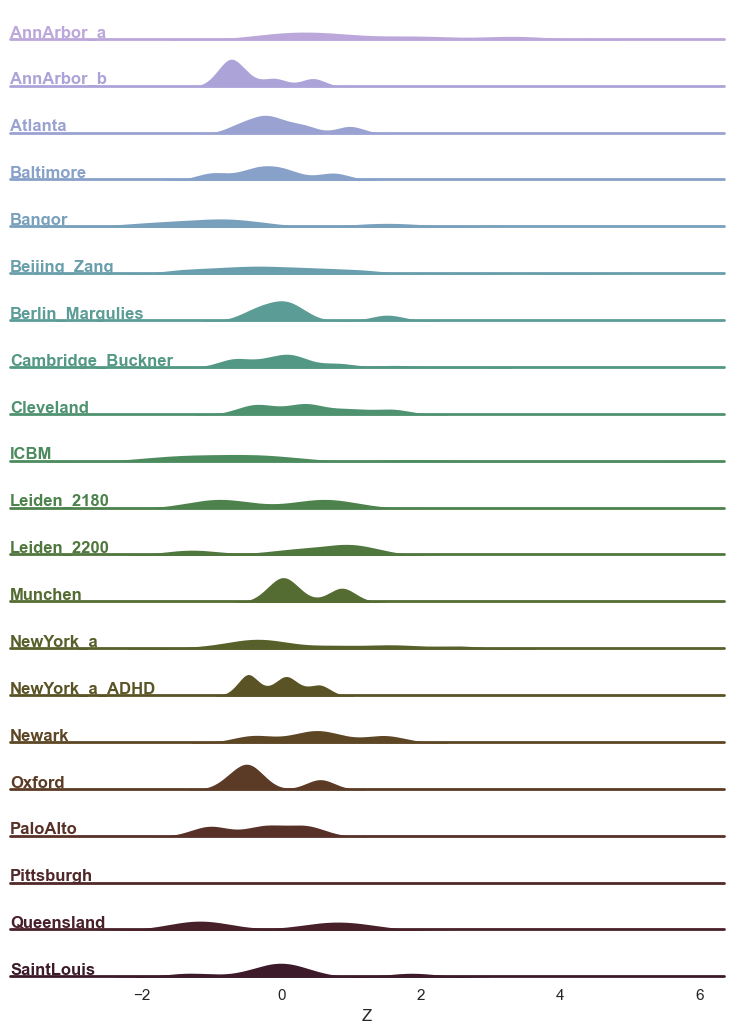

In [14]:
# Show the distribution of predicted Z-scores per site
plot_ridge(test, "Z", "site")

/opt/anaconda3/envs/uv_refactor/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/envs/uv_refactor/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/envs/uv_refactor/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/envs/uv_refactor/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  

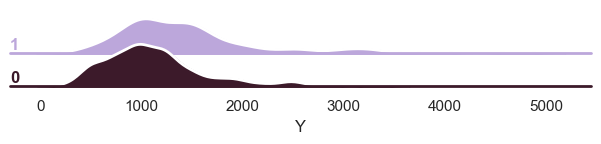

/opt/anaconda3/envs/uv_refactor/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/envs/uv_refactor/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/envs/uv_refactor/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/envs/uv_refactor/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  

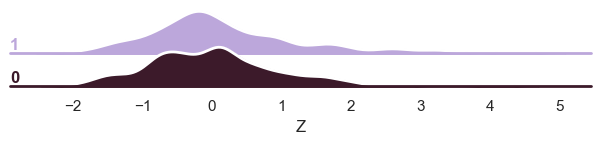

In [16]:
# Show the distribution of predicted Z-scores per site
plot_ridge(test, "Y", "sex")
plot_ridge(test, "Z", "sex")

In [17]:
# Remove the Z-scores if they exist (for demonstration purposes)
if hasattr(test, "Z"):
    del test["Z"]

# Get new Z-scores
model.predict(test)

# Display the Z-scores
display(test["Z"].to_pandas())

response_vars,WM-hypointensities
observations,
515,-0.296410
441,-0.528196
1029,0.574404
64,0.327241
654,-0.770792
...,...
611,1.766515
549,1.590130
640,-0.880070


### Transfer and extend

We can transfer the model to a new dataset with new sites. Then we will be able to use it on the new dataset.

We can also extend the model to a new dataset. Then we will be able to use it on the new dataset as well as the old one.

Both are possible without access to the original data.

Isn't that cool?

In [18]:
# Turn this back on
model.savemodel = True
model.saveresults = True
model.saveplots = True
model.evaluate_model = True

In [26]:
# Transfer the model to a new dataset
transfered_model = model.transfer_predict(transfer_train, transfer_test, freedom=1.0)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,1,0.20,31
,2000,2,0.20,63
,2000,5,0.23,15
,2000,3,0.24,31


<xarray.NormData> Size: 6kB
Dimensions:            (observations: 30, response_vars: 1, covariates: 1,
                        batch_effect_dims: 2, centile: 5, statistic: 10)
Coordinates:
  * observations       (observations) int64 240B 951 953 915 943 ... 973 908 976
  * response_vars      (response_vars) <U18 72B 'WM-hypointensities'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 320B 'MACE' 'MAPE' ... 'SMSE' 'ShapiroW'
Data variables:
    subjects           (observations) object 240B 'Oulu_sub72795' ... 'Oulu_s...
    Y                  (observations, response_vars) float64 240B 1.287e+03 ....
    X                  (observations, covariates) float64 240B 21.0 ... 21.0
    batch_effects      (observations, batch_effect_dims) <U11 3kB '0' ... 'Oulu'
    Z                  (observations, response_vars) float64 240B 0.0839 ... ...
    centiles           (centile, observations, response_vars) float64 1kB 737...
    logp               (observations, response_vars) float64 240B -0.1018 ......
    Y_harmonized       (observations, response_vars) float64 240B 1.162e+03 ....
    Yhat               (observations, response_vars) float64 240B 0.08675 ......
    statistics         (response_vars, statistic) float64 80B 0.07333 ... 0.988
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           transfer_test
    unique_batch_effects:           {'sex': ['0', '1'], 'site': ['Milwaukee_b...
    batch_effect_counts:            {'sex': {'0': 96, '1': 52}, 'site': {'Mil...
    batch_effect_covariate_ranges:  {'sex': {'0': {'age': {'min': 20.0, 'max'...
    covariate_ranges:               {'age': {'min': 20.0, 'max': 65.0}}

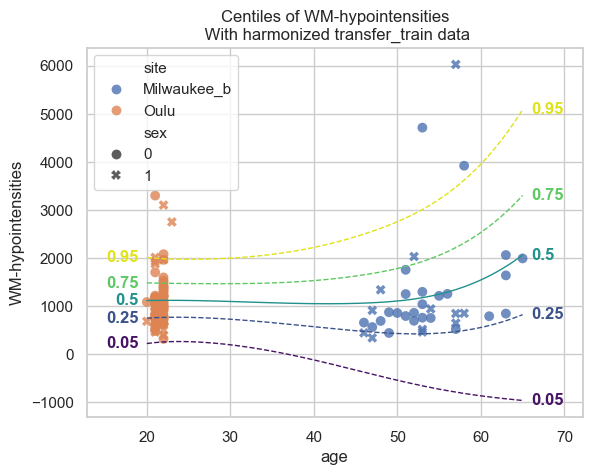

In [27]:
plot_centiles(
    model=transfered_model,
    covariate="age",
    batch_effects="all",
    scatter_data=transfer_train,
    show_other_data=True,
    harmonize_data=True,
    show_legend=True,
)

In [29]:
# And extend the model to a new dataset
extended_model = model.extend_predict(transfer_train, transfer_test)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,20,0.10,63
,2000,16,0.12,31
,2000,7,0.11,127
,2000,10,0.13,95


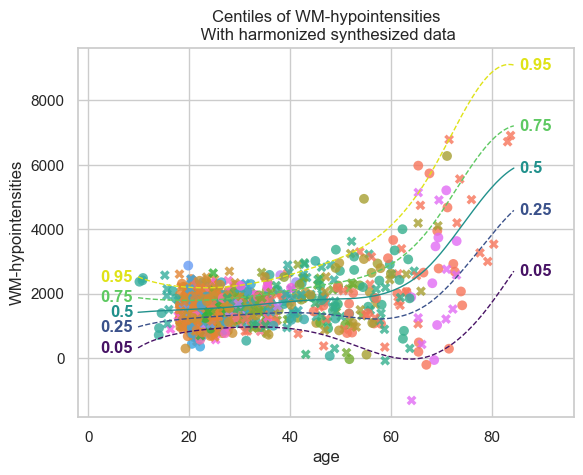

In [23]:
plot_centiles(
    extended_model,
    covariate="age",
    batch_effects="all",
    show_other_data=True,
    harmonize_data=True,
    show_legend=False,
    scatter_data=extended_model.synthesize(covariate_range_per_batch_effect=True),
)


## Next steps

- Check out the [runner example](runner_example.ipynb) to see how to fit and evaluate a model in parallel and in K-fold cross validation on a cluster using the runner class.
- Check out the [command line interface](command_line_interface.ipynb) example to see how to use the pcntoolkit from the command line.
- Try some of the regression models down here. Just substitute the `HBR` model with one of the other models.


In [31]:
# SHASHb model with fixed values for epsilon and delta
mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        sigma=make_prior(dist_name="Gamma", dist_params=(3.0, 1.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

epsilon = make_prior(
    dist_name="Normal",
    dist_params=(0.0, 1.0),
)

delta = make_prior(
    dist_name="Normal",
    dist_params=(1.0, 1.0),
    mapping="softplus",
    mapping_params=(
        0.0,
        3.0,  # Scale for smoothness
        0.6,  # We need to provide a vertical shift as well, because the SHASH mapping goes a bit wild with low values for delta
    ),
)

shashb1_regression_model = HBR(
    name="template",
    cores=16,
    progressbar=True,
    draws=1500,
    tune=500,
    chains=4,
    nuts_sampler="nutpie",
    likelihood=SHASHbLikelihood(mu, sigma, epsilon, delta),
)

In [32]:
# SHASHb model with linear regression in epsilon and delta
mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        sigma=make_prior(dist_name="Gamma", dist_params=(3.0, 1.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

epsilon = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)

delta = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(
        0.0,
        3.0,  # Scale for smoothness
        0.6,  # We need to provide a vertical shift as well, because the SHASH mapping goes a bit wild with low values for delta
    ),
)

shashb2_regression_model = HBR(
    name="template",
    cores=16,
    progressbar=True,
    draws=1500,
    tune=500,
    chains=4,
    nuts_sampler="nutpie",
    likelihood=SHASHbLikelihood(mu, sigma, epsilon, delta),
)

In [33]:
# BLR model
template_blr = BLR(
    name="template",
    n_iter=1000,
    tol=1e-8,
    optimizer="l-bfgs-b",
    l_bfgs_b_epsilon=0.1,
    l_bfgs_b_l=0.1,
    l_bfgs_b_norm="l2",
    fixed_effect=True,
    basis_function_mean=BsplineBasisFunction(basis_column=0, degree=3, nknots=5),
    heteroskedastic=True,
    basis_function_var=BsplineBasisFunction(basis_column=0, degree=3, nknots=5),
    fixed_effect_var=True,
)

In [34]:
# Creating a normative model with keyword arguments only
# Useful for procedural model creation
model = NormativeModel.from_args(
    alg="hbr",
    likelihood="Normal",
    linear_mu=True,
    random_intercept_mu=True,
    dist_name_sigma_intercept_mu="Gamma",
    dist_params_sigma_intercept_mu=(3.0, 1.0),
    basis_function_mu="bspline",
    basis_function_mu_nknots=4,
    basis_function_mu_left_expand=0.1,
    basis_function_mu_right_expand=0.05,
    basis_function_mu_knot_method="uniform",
    linear_sigma=True,
    mapping_sigma="softplus",
    mapping_params_sigma=(0.0, 3.0),
    random_intercept_sigma=True,
    dist_name_sigma_intercept_sigma="Normal",
    dist_params_sigma_intercept_sigma=(3.0, 1.0),
    mapping_sigma_intercept_sigma="softplus",
    draws=2048,
    tune=512,
    cores=8,
    chains=4,
    nuts_sampler="nutpie",
)
template: HBR = model.template_regression_model  # type: ignore
print(template.draws)
print(template.tune)
print(template.cores)
print(template.chains)
print(template.nuts_sampler)

2048
512
8
4
nutpie
